# 🚗 Saudi Used Cars Market Analysis

### Project 01 - Python for Data Analysis

**By:** Hala Mohsen Jan

## Project Objective

Analyze the Saudi used cars market to discover pricing trends, understand the characteristics of listed vehicles, and generate business insights using Python, Pandas, and NumPy.

In [1]:
import pandas as pd
import numpy as np

In [16]:
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("UsedCarsSA_Clean_EN.csv")

In [3]:
df.head()

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,0,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500,False


In [4]:
df.shape

(8035, 13)

In [5]:
df.columns

Index(['Make', 'Type', 'Year', 'Origin', 'Color', 'Options', 'Engine_Size',
       'Fuel_Type', 'Gear_Type', 'Mileage', 'Region', 'Price', 'Negotiable'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8035 non-null   object 
 1   Type         8035 non-null   object 
 2   Year         8035 non-null   int64  
 3   Origin       8035 non-null   object 
 4   Color        8035 non-null   object 
 5   Options      8035 non-null   object 
 6   Engine_Size  8035 non-null   float64
 7   Fuel_Type    8035 non-null   object 
 8   Gear_Type    8035 non-null   object 
 9   Mileage      8035 non-null   int64  
 10  Region       8035 non-null   object 
 11  Price        8035 non-null   int64  
 12  Negotiable   8035 non-null   bool   
dtypes: bool(1), float64(1), int64(3), object(8)
memory usage: 761.3+ KB


In [7]:
df.describe()

,Year,Engine_Size,Mileage,Price
count,8035.000000,8035.000000,8.035000e+03,8.035000e+03
mean,2014.097698,3.287729,1.491488e+05,5.369984e+04
std,5.757228,1.517747,3.474480e+05,7.198472e+04
min,1963.000000,1.000000,1.000000e+02,0.000000e+00
25%,2012.000000,2.000000,3.700000e+04,0.000000e+00
50%,2016.000000,3.000000,1.019600e+05,3.700000e+04
75%,2018.000000,4.400000,1.950000e+05,7.375000e+04
max,2022.000000,9.000000,2.000000e+07,1.150000e+06


# after exploring the data i recognize:

The dataset contains 8,035 used cars with 13 attributes describing each vehicle. There are no missing values, indicating that the dataset is complete and ready for analysis. The features include categorical, numerical, and boolean variables such as car brand, model year, mileage, price, and negotiation status.

In [8]:
df['Make'].value_counts()

,count
Make,
Toyota,2038
Hyundai,941
Ford,763
Chevrolet,644
Nissan,548
GMC,400
Kia,357
Lexus,343
Mercedes,328


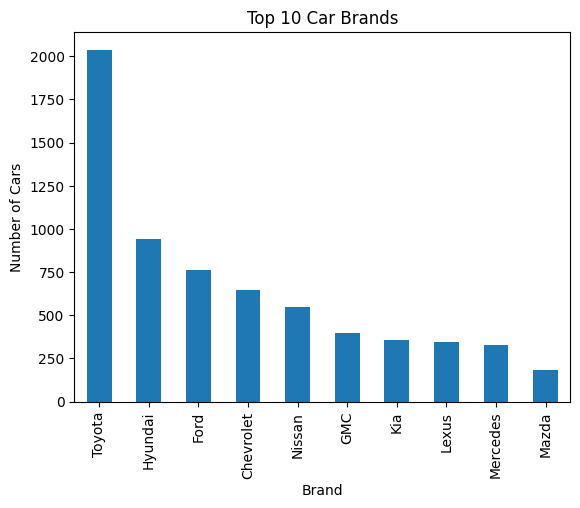

In [17]:
top10 = df['Make'].value_counts().head(10)

top10.plot(kind='bar')

plt.title('Top 10 Car Brands')
plt.xlabel('Brand')
plt.ylabel('Number of Cars')

plt.show()

Toyota is the most frequently listed used car brand in the dataset, with a significantly higher number of listings than all other brands. Hyundai and Ford rank second and third, respectively.

# Business Insight

This suggests that Toyota dominates the Saudi used car market, making it an important brand for further pricing and demand analysis.

In [18]:
df.groupby('Make')['Price'].mean().sort_values(ascending=False).head(10)

,Price
Make,
Rolls-Royce,532500.000000
Bentley,393928.571429
Aston Martin,376666.666667
Ferrari,280000.000000
Land Rover,186392.857143
Maserati,162687.500000
Mercedes,134004.573171
Porsche,121484.848485
Lexus,117942.274052


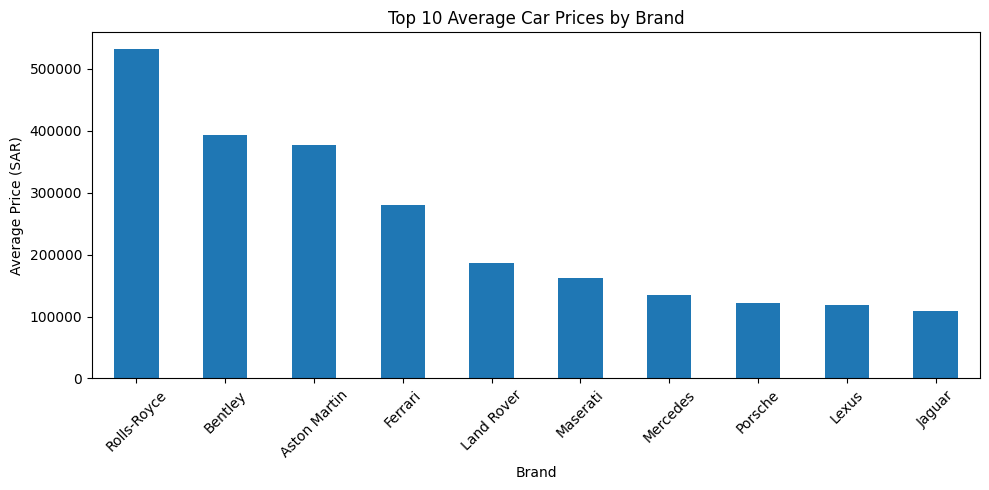

In [19]:
top_price = df.groupby('Make')['Price'].mean().sort_values(ascending=False).head(10)

top_price.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Average Car Prices by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price (SAR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Luxury brands such as Rolls-Royce, Bentley, and Ferrari have the highest average prices in the Saudi used car market. This reflects their premium positioning and strong resale value compared with mass-market brands.

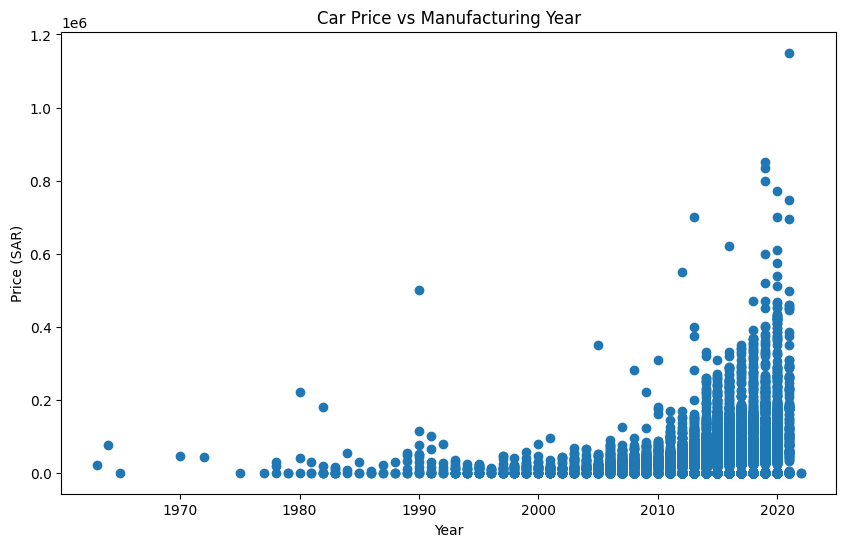

In [20]:
plt.figure(figsize=(10,6))

plt.scatter(df['Year'], df['Price'])

plt.title("Car Price vs Manufacturing Year")
plt.xlabel("Year")
plt.ylabel("Price (SAR)")

plt.show()

The scatter plot shows a positive relationship between manufacturing year and car price. Newer vehicles generally have higher prices, although there is considerable variation within the same model year.

# Business Insight

Vehicle age is an important factor affecting price, but it is not the only one. Other variables such as brand, mileage, engine size, and vehicle condition likely play significant roles in determining the final selling price.

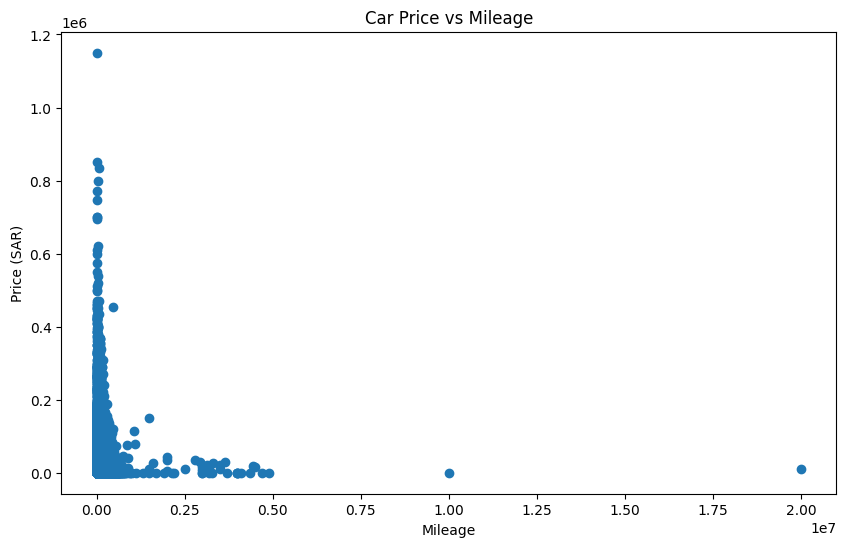

In [21]:
plt.figure(figsize=(10,6))

plt.scatter(df['Mileage'], df['Price'])

plt.title("Car Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price (SAR)")

plt.show()

The scatter plot indicates a negative relationship between mileage and price. Cars with lower mileage generally have higher prices, while vehicles with high mileage tend to be less expensive.

# Business Insight

Mileage is one of the key factors affecting used car prices. However, several outliers with extremely high mileage suggest potential data quality issues that should be investigated before building predictive models.

In [10]:
df['Region'].value_counts()

,count
Region,
Riyadh,3237
Dammam,1370
Jeddah,1054
Qassim,309
Al-Medina,297
Al-Ahsa,235
Aseer,231
Makkah,227
Taef,137


In [11]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Gas,7861
Diesel,151
Hybrid,23


In [12]:
df['Gear_Type'].value_counts()

,count
Gear_Type,
Automatic,6971
Manual,1064


In [13]:
df['Price'].mean()

np.float64(53699.83584318606)

In [14]:
df['Price'].max()

1150000

In [15]:
df['Price'].min()

0

# **(Data Cleaning)**

In [22]:
df.duplicated().sum()

np.int64(3)

In [23]:
df.sort_values(by='Mileage', ascending=False).head(10)

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
7391,Chevrolet,Optra,2009,Other,Another Color,Semi Full,1.6,Gas,Manual,20000000,Riyadh,9000,False
4475,Mercedes,POS24,1983,Other,Another Color,Full,8.0,Diesel,Manual,9999999,Aseer,0,True
5068,Toyota,Aurion,2010,Saudi,White,Standard,3.5,Gas,Automatic,4900000,Qassim,0,True
4675,Chevrolet,Tahoe,2012,Saudi,Golden,Semi Full,5.3,Gas,Automatic,4691232,Al-Jouf,0,True
7525,Toyota,Camry,1998,Other,Grey,Full,2.5,Gas,Automatic,4500000,Yanbu,15000,False
6616,Toyota,Camry,2008,Gulf Arabic,Grey,Semi Full,2.0,Gas,Automatic,4430000,Al-Ahsa,17500,False
7270,GMC,C5700,1977,Saudi,Red,Standard,1.5,Gas,Manual,4358765,Hafar Al-Batin,0,True
1564,Nissan,Pathfinder,2002,Saudi,Black,Full,3.5,Gas,Manual,4090000,Aseer,0,True
3404,GMC,Suburban,2005,Saudi,Bronze,Semi Full,8.0,Gas,Automatic,4010000,Riyadh,0,True
5539,Toyota,Land Cruiser,2006,Other,White,Semi Full,4.7,Gas,Automatic,4000000,Riyadh,0,True


In [24]:
df = df.drop_duplicates()

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
region_price = df.groupby('Region')['Price'].mean().sort_values(ascending=False)

region_price

,Price
Region,
Dammam,76519.915936
Riyadh,57742.516069
Jeddah,56009.611954
Khobar,50157.195652
Al-Ahsa,44806.757447
Makkah,39863.788546
Qassim,38569.466019
Aseer,37511.225108
Jazan,36371.255556


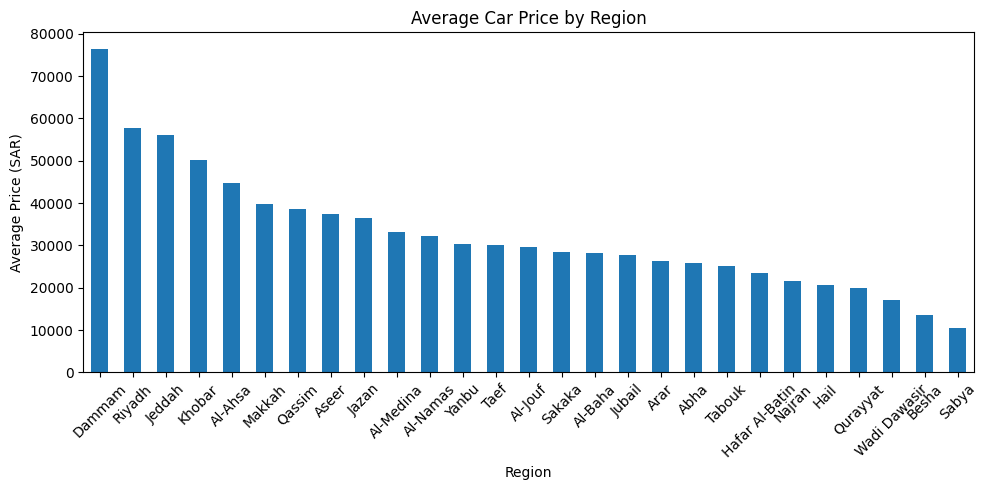

In [27]:
region_price.plot(kind='bar', figsize=(10,5))

plt.title("Average Car Price by Region")
plt.xlabel("Region")
plt.ylabel("Average Price (SAR)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The average used car price varies considerably across regions. Dammam records the highest average prices, followed by Riyadh and Jeddah. This may reflect differences in local demand, income levels, and the types of vehicles available in each region.

**هل السيارات القابلة للتفاوض أرخص؟**

In [28]:
df.groupby('Negotiable')['Price'].mean()

,Price
Negotiable,
False,78320.715635
True,0.000000


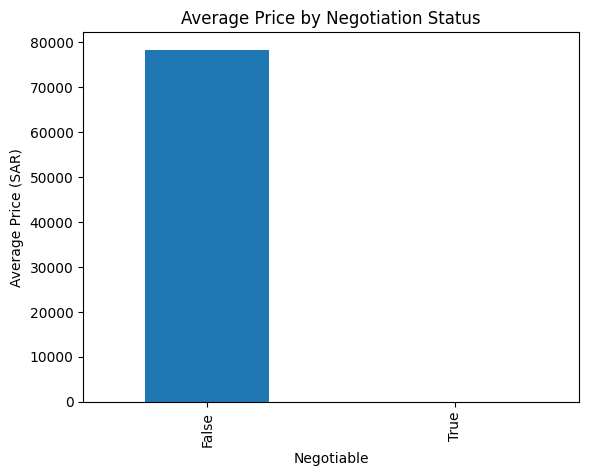

In [29]:
neg_price = df.groupby('Negotiable')['Price'].mean()

neg_price.plot(kind='bar')

plt.title("Average Price by Negotiation Status")
plt.xlabel("Negotiable")
plt.ylabel("Average Price (SAR)")

plt.show()

In [32]:
df[df["Negotiable"] == True].head()

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,0,True
7,GMC,Yukon,2009,Saudi,Bronze,Full,5.7,Gas,Automatic,323000,Riyadh,0,True
18,GMC,Yukon,2018,Saudi,White,Full,5.3,Gas,Automatic,37000,Riyadh,0,True
26,Toyota,Camry,2019,Saudi,Red,Full,2.5,Gas,Automatic,8000,Makkah,0,True
28,Toyota,Avalon,2008,Other,Red,Full,3.5,Gas,Automatic,169000,Riyadh,0,True


In [33]:
df[df["Negotiable"] == True]["Price"].describe()

,Price
count,2525.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


**Note:** Cars marked as negotiable have a recorded price of 0 in the dataset. Therefore, this feature was not used for price comparison because it does not represent the actual market value.

**متوسط السعر حسب نوع الوقود**

In [34]:
fuel_price = df.groupby("Fuel_Type")["Price"].mean().sort_values(ascending=False)

print(fuel_price)

Fuel_Type
Hybrid    72051.956522
Diesel    55699.980132
Gas       53607.061466
Name: Price, dtype: float64


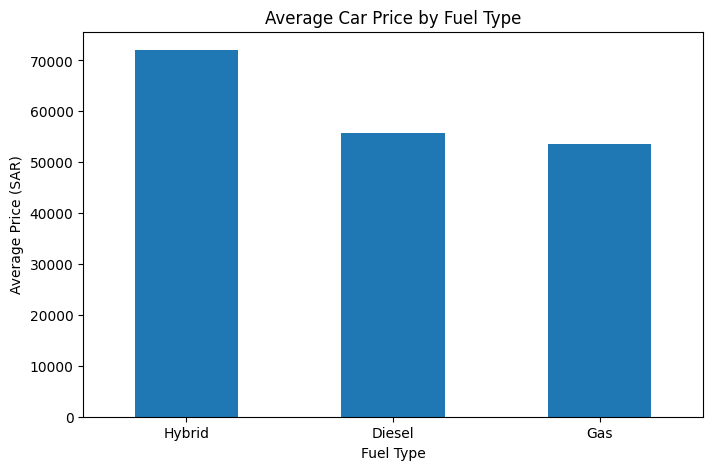

In [35]:
fuel_price.plot(kind='bar', figsize=(8,5))

plt.title("Average Car Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price (SAR)")

plt.xticks(rotation=0)

plt.show()

Hybrid vehicles have the highest average selling price in the dataset, followed by diesel vehicles. Gas-powered cars are the most common but have the lowest average price among the three fuel types.

**أكثر أنواع الوقود انتشارًا**

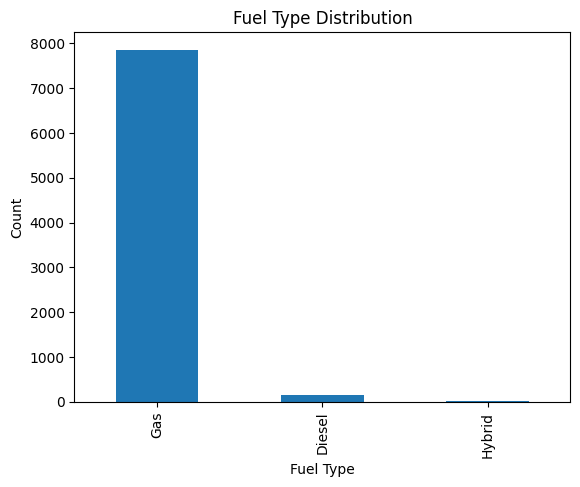

In [30]:
fuel = df['Fuel_Type'].value_counts()

fuel.plot(kind='bar')

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.show()

**أكثر أنواع القير انتشارا**

In [36]:
gear_price = df.groupby("Gear_Type")["Price"].mean().sort_values(ascending=False)

print(gear_price)

Gear_Type
Automatic    57649.628444
Manual       27828.543233
Name: Price, dtype: float64


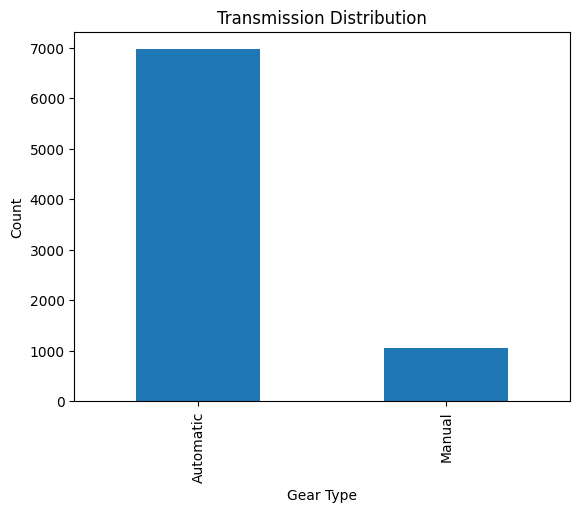

In [31]:
gear = df['Gear_Type'].value_counts()

gear.plot(kind='bar')

plt.title("Transmission Distribution")
plt.xlabel("Gear Type")
plt.ylabel("Count")

plt.show()

Automatic transmission vehicles dominate the dataset and have a significantly higher average price than manual vehicles. This may indicate stronger market demand for automatic cars or that newer vehicles are predominantly equipped with automatic transmissions.

**هل حجم المحرك يؤثر على السعر؟**

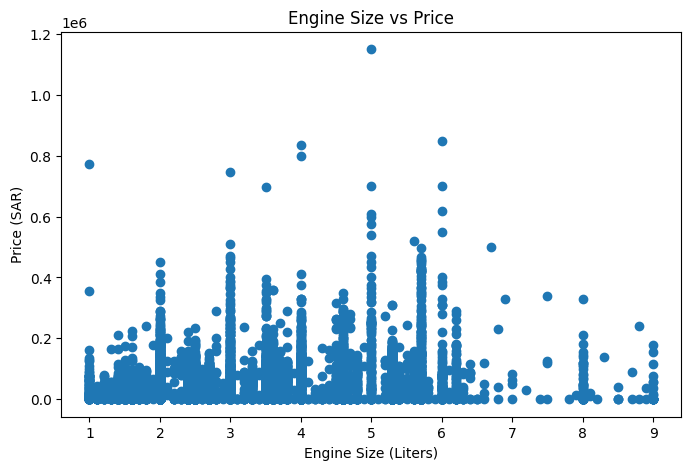

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(df["Engine_Size"], df["Price"])

plt.title("Engine Size vs Price")
plt.xlabel("Engine Size (Liters)")
plt.ylabel("Price (SAR)")

plt.show()

In [38]:
df[["Engine_Size","Price"]].corr()

,Engine_Size,Price
Engine_Size,1.000000,0.155766
Price,0.155766,1.000000


A weak positive correlation (0.16) exists between engine size and vehicle price. Although larger engines tend to be associated with higher prices, engine size alone is not a strong predictor of price.

# Business Insight

Other factors such as brand, manufacturing year, mileage, and vehicle condition likely have a greater influence on the selling price than engine size alone.

أكثر موديلات السيارات انتشارًا

Type
Land Cruiser    372
Camry           328
Hilux           290
Accent          250
Yukon           230
Tahoe           218
Sonata          213
Taurus          203
Elantra         189
Corolla         171
Name: count, dtype: int64


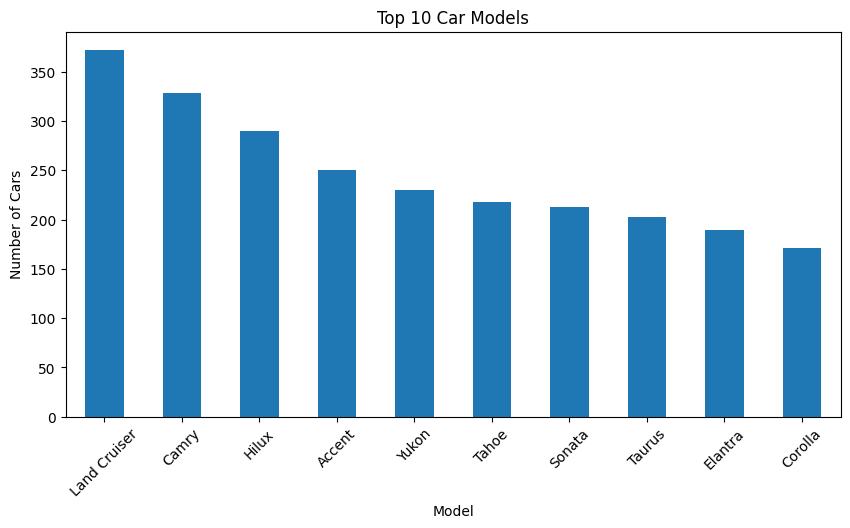

In [39]:
top_types = df["Type"].value_counts().head(10)

print(top_types)

top_types.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Car Models")
plt.xlabel("Model")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45)

plt.show()

In [40]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

corr

,Year,Engine_Size,Mileage,Price
Year,1.000000,-0.236150,-0.214511,0.292662
Engine_Size,-0.236150,1.000000,0.050579,0.155766
Mileage,-0.214511,0.050579,1.000000,-0.102911
Price,0.292662,0.155766,-0.102911,1.000000


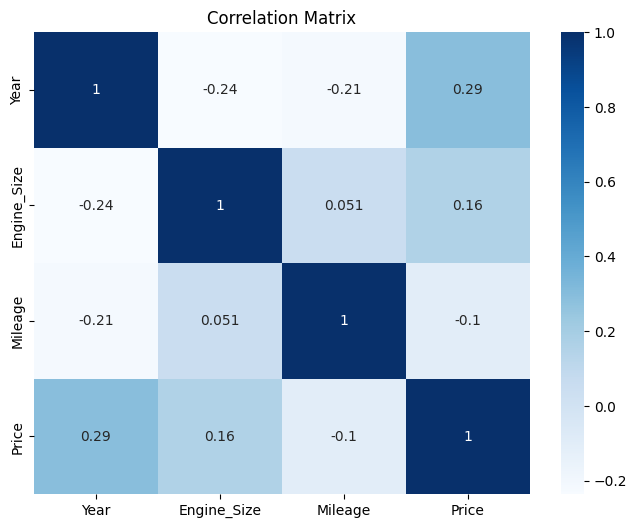

In [41]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="Blues")

plt.title("Correlation Matrix")

plt.show()